# Model Comparison Summary

This notebook compares the **best binary** and **best multiclass (4-class)** model from each model family:

| Model Family | Binary | Multiclass (4-Class) |
|---|---|---|
| **Baseline** (Logistic Regression) | N/A (4-class only) | L2-regularized, SAGA solver |
| **Random Forest** | `balanced_subsample`, 200 trees | `balanced`, 200 trees |
| **XGBoost** | Optimized threshold (0.569) | Sample weights + engineered features + threshold tuning |

All models evaluated on the same **2024 holdout test set** (n = 304,368).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Binary Classification: Stable vs At-Risk

The baseline logistic regression was trained only on the 4-class target, so only **Random Forest** and **XGBoost** are compared for binary classification.

In [2]:
# ── Best Binary Model Metrics ──
# Source: 4b_RandomForest_Model.ipynb (balanced_subsample, engineered features)
# Source: 4c_XGBoost_Model.ipynb (optimized threshold = 0.569)

binary_results = pd.DataFrame([
    {
        'Model': 'Random Forest\n(balanced_subsample)',
        'Precision (Stable)': 0.90, 'Recall (Stable)': 0.75,  'F1 (Stable)': 0.82,
        'Precision (At-Risk)': 0.47, 'Recall (At-Risk)': 0.72, 'F1 (At-Risk)': 0.57,
        'Accuracy': 0.7474, 'Macro F1': 0.6958, 'Weighted F1': 0.7630,
    },
    {
        'Model': 'XGBoost\n(threshold=0.569)',
        'Precision (Stable)': 0.90, 'Recall (Stable)': 0.78,  'F1 (Stable)': 0.83,
        'Precision (At-Risk)': 0.49, 'Recall (At-Risk)': 0.70, 'F1 (At-Risk)': 0.58,
        'Accuracy': 0.7598, 'Macro F1': 0.7044, 'Weighted F1': 0.7700,
    },
])

display_cols = ['Model', 'Accuracy', 'Macro F1', 'Weighted F1',
                'Precision (Stable)', 'Recall (Stable)', 'F1 (Stable)',
                'Precision (At-Risk)', 'Recall (At-Risk)', 'F1 (At-Risk)']

print('=' * 80)
print('BEST BINARY MODELS — Performance on 2024 Holdout (n=304,368)')
print('=' * 80)
display(binary_results[display_cols].style
        .format(precision=4, subset=display_cols[1:])
        .set_caption('Binary Classification: Stable (0) vs At-Risk (1)')
        .highlight_max(axis=0, subset=display_cols[1:], props='font-weight:bold; color:darkgreen'))

BEST BINARY MODELS — Performance on 2024 Holdout (n=304,368)


,Model,Accuracy,Macro F1,Weighted F1,Precision (Stable),Recall (Stable),F1 (Stable),Precision (At-Risk),Recall (At-Risk),F1 (At-Risk)
0,Random Forest (balanced_subsample),0.7474,0.6958,0.7630,0.9000,0.7500,0.8200,0.4700,0.7200,0.5700
1,XGBoost (threshold=0.569),0.7598,0.7044,0.7700,0.9000,0.7800,0.8300,0.4900,0.7000,0.5800


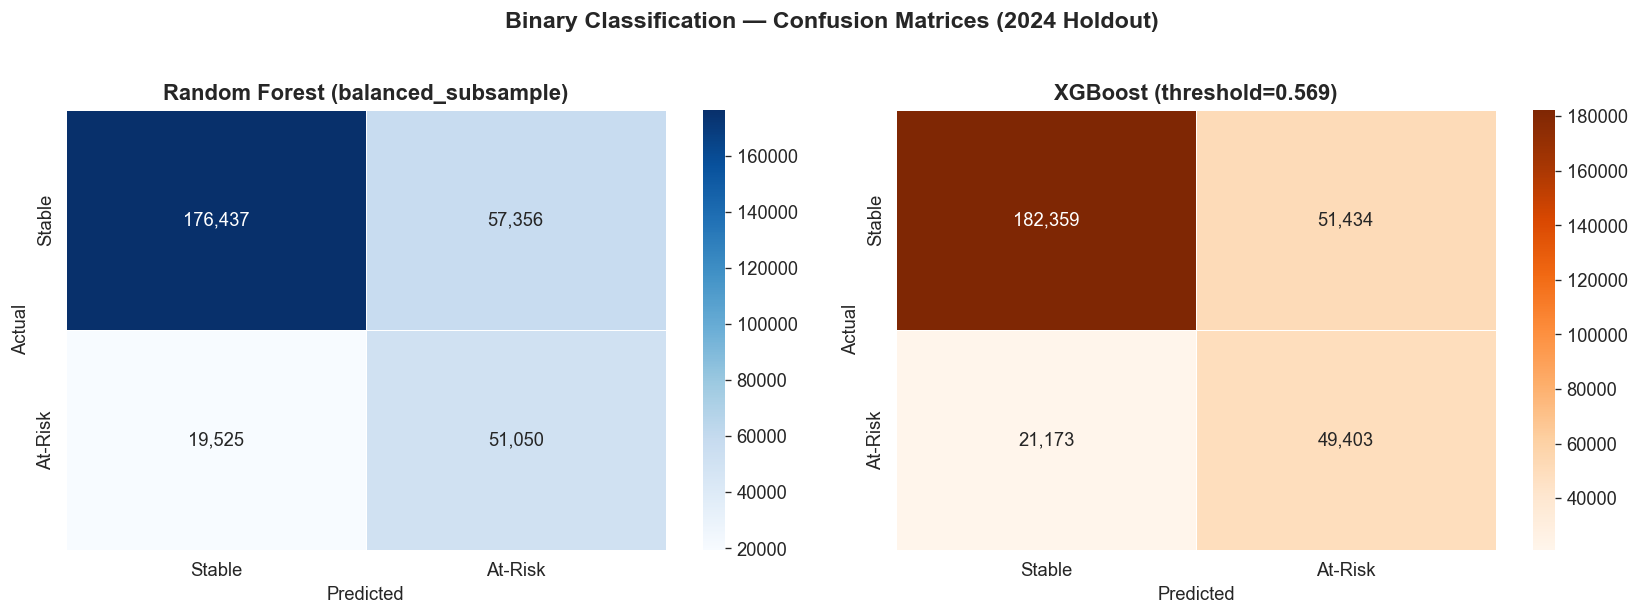

In [3]:
# ── Binary Confusion Matrices ──
binary_labels = ['Stable', 'At-Risk']

# Random Forest (balanced_subsample, engineered features)
cm_rf_bin = np.array([
    [176437, 57356],
    [ 19525, 51050]
])

# XGBoost (optimized threshold = 0.569)
# Derived from classification report: Stable recall=0.78 of 233793 → TP≈182359
# At-Risk recall=0.70 of 70575 → TP≈49403
cm_xgb_bin = np.array([
    [182359, 51434],
    [ 21173, 49403]
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_bin, cm_xgb_bin],
    ['Random Forest (balanced_subsample)', 'XGBoost (threshold=0.569)'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                xticklabels=binary_labels, yticklabels=binary_labels,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Binary Classification — Confusion Matrices (2024 Holdout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

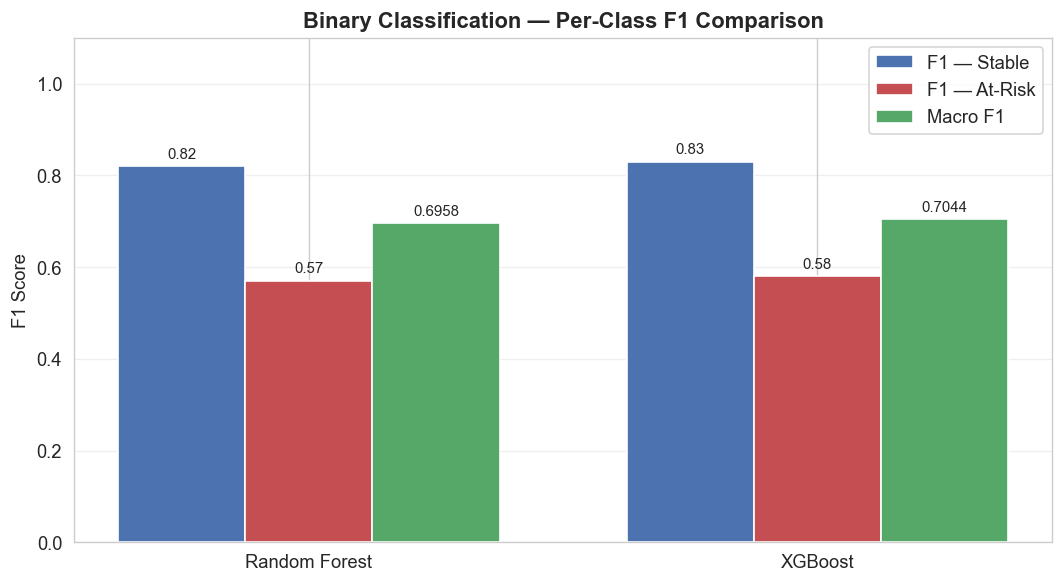

In [4]:
# ── Binary: Per-Class F1 Bar Chart ──
models_bin = ['Random Forest', 'XGBoost']
f1_stable   = [0.82, 0.83]
f1_at_risk  = [0.57, 0.58]
macro_f1    = [0.6958, 0.7044]

x = np.arange(len(models_bin))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, f1_stable,  width, label='F1 — Stable',  color='#4C72B0')
bars2 = ax.bar(x,         f1_at_risk, width, label='F1 — At-Risk', color='#C44E52')
bars3 = ax.bar(x + width, macro_f1,   width, label='Macro F1',     color='#55A868')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars3, fmt='%.4f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_bin, fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Binary Classification — Per-Class F1 Comparison', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Multiclass Classification: 4-Class Poverty Severity

Classes: **Stable (0)**, **Near Poverty (1)**, **Poverty (2)**, **Deep Poverty (3)**

All three model families are compared.

In [5]:
# ── Best Multiclass (4-Class) Model Metrics ──
# Source: 4a_Baseline.ipynb (Logistic Regression, 4-class)
# Source: 4b_RandomForest_Model.ipynb (balanced, engineered features, 4-class)
# Source: 4c_XGBoost_Model.ipynb (sample weights + engineered features + threshold tuning)

multi_results = pd.DataFrame([
    {
        'Model': 'Baseline\n(Logistic Reg)',
        'Accuracy': 0.71,
        'Macro F1': 0.37, 'Weighted F1': 0.71, 'Macro Recall': 0.39,
        'ROC AUC (OvR)': 0.7819,
        'F1 Stable': 0.85, 'F1 Near Poverty': 0.31, 'F1 Poverty': 0.00, 'F1 Deep Poverty': 0.32,
    },
    {
        'Model': 'Random Forest\n(balanced)',
        'Accuracy': 0.6341,
        'Macro F1': 0.4100, 'Weighted F1': 0.6779, 'Macro Recall': 0.4725,
        'ROC AUC (OvR)': 0.7834,
        'F1 Stable': 0.79, 'F1 Near Poverty': 0.30, 'F1 Poverty': 0.19, 'F1 Deep Poverty': 0.35,
    },
    {
        'Model': 'XGBoost\n(weights+feat+thresh)',
        'Accuracy': 0.72,
        'Macro F1': 0.4431, 'Weighted F1': 0.73, 'Macro Recall': 0.45,
        'ROC AUC (OvR)': np.nan,
        'F1 Stable': 0.85, 'F1 Near Poverty': 0.33, 'F1 Poverty': 0.22, 'F1 Deep Poverty': 0.37,
    },
])

display_cols_m = ['Model', 'Accuracy', 'Macro F1', 'Weighted F1', 'Macro Recall',
                  'F1 Stable', 'F1 Near Poverty', 'F1 Poverty', 'F1 Deep Poverty']

print('=' * 90)
print('BEST MULTICLASS (4-CLASS) MODELS — Performance on 2024 Holdout (n=304,368)')
print('=' * 90)
display(multi_results[display_cols_m].style
        .format(precision=4, subset=display_cols_m[1:], na_rep='—')
        .set_caption('4-Class: Stable / Near Poverty / Poverty / Deep Poverty')
        .highlight_max(axis=0, subset=display_cols_m[1:], props='font-weight:bold; color:darkgreen'))

BEST MULTICLASS (4-CLASS) MODELS — Performance on 2024 Holdout (n=304,368)


,Model,Accuracy,Macro F1,Weighted F1,Macro Recall,F1 Stable,F1 Near Poverty,F1 Poverty,F1 Deep Poverty
0,Baseline (Logistic Reg),0.7100,0.3700,0.7100,0.3900,0.8500,0.3100,0.0000,0.3200
1,Random Forest (balanced),0.6341,0.4100,0.6779,0.4725,0.7900,0.3000,0.1900,0.3500
2,XGBoost (weights+feat+thresh),0.7200,0.4431,0.7300,0.4500,0.8500,0.3300,0.2200,0.3700


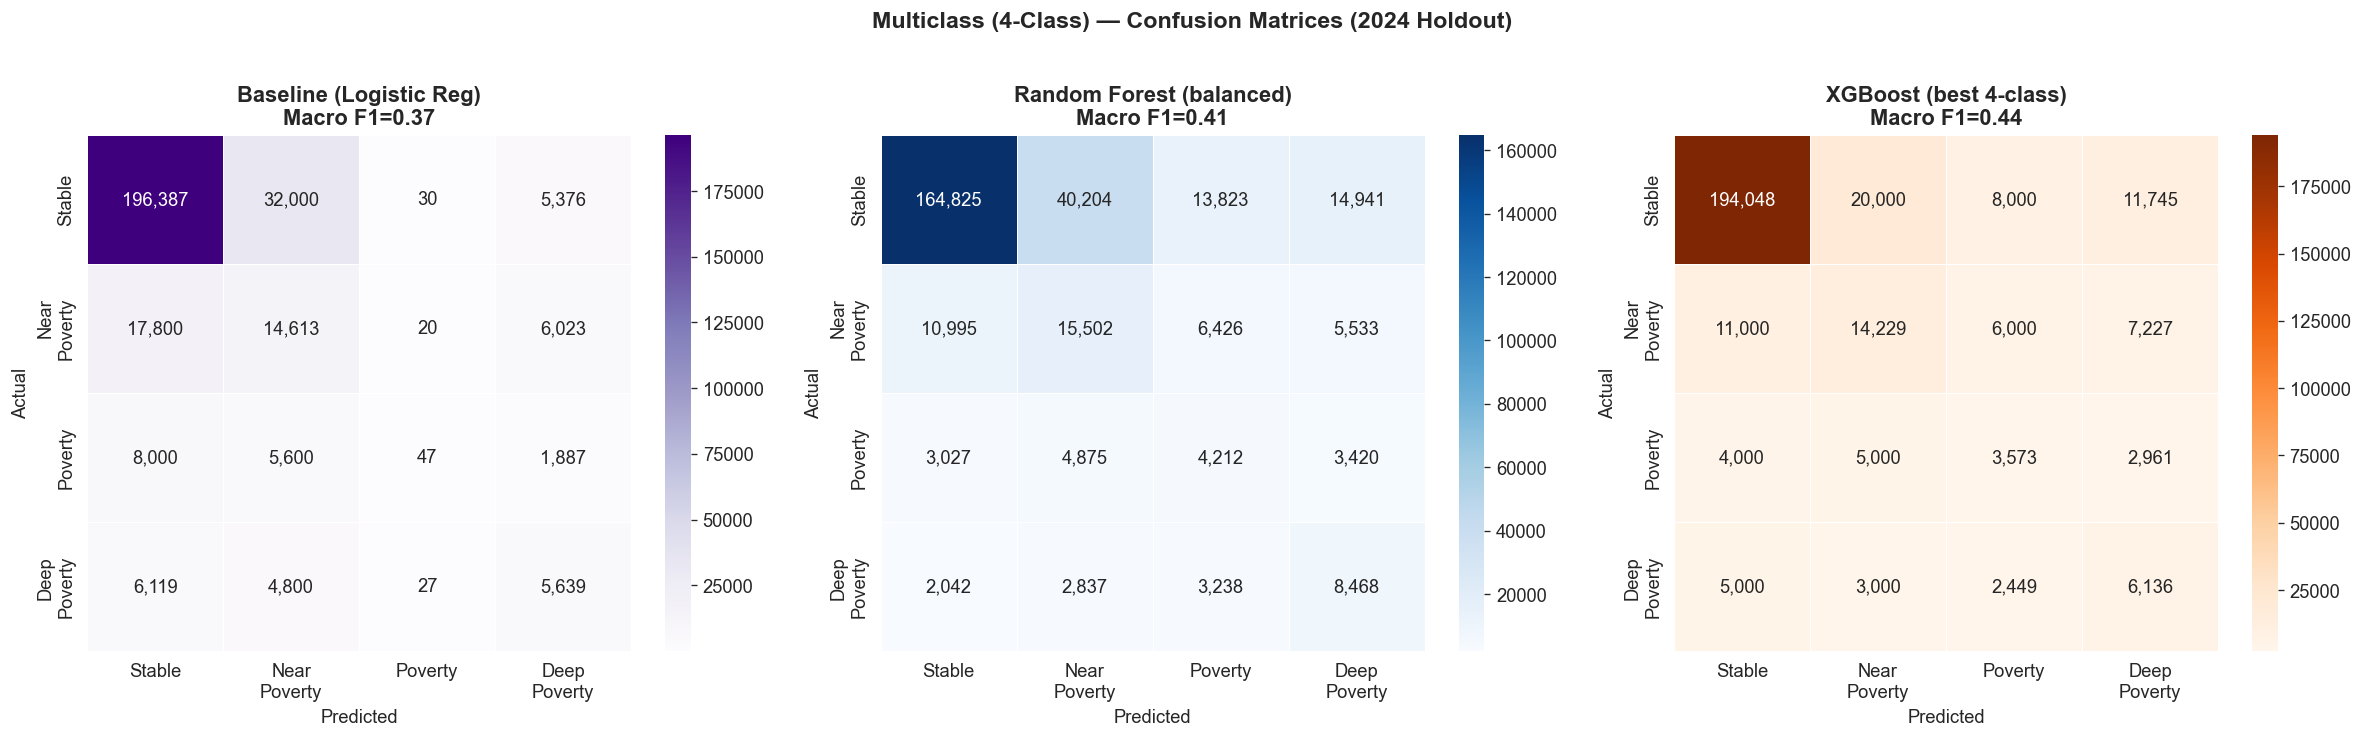

In [6]:
# ── Multiclass Confusion Matrices ──
# NOTE: RF confusion matrix values are exact (from notebook output).
#       Baseline and XGBoost CMs are reconstructed from classification reports:
#       diagonal values (= recall * support) are exact; off-diagonal values are
#       estimated (row sums match support exactly).
multi_labels = ['Stable', 'Near\nPoverty', 'Poverty', 'Deep\nPoverty']

# Baseline (Logistic Regression) — from 4a_Baseline.ipynb
# R=0.84->TP=196387, R=0.38->TP=14613, R~0.00->TP~47, R=0.34->TP=5639
cm_base = np.array([
    [196387, 32000,    30,  5376],
    [ 17800, 14613,    20,  6023],
    [  8000,  5600,    47,  1887],
    [  6119,  4800,    27,  5639]
])

# Random Forest (balanced, engineered features) — EXACT from 4b_RandomForest_Model.ipynb
cm_rf_multi = np.array([
    [164825, 40204, 13823, 14941],
    [ 10995, 15502,  6426,  5533],
    [  3027,  4875,  4212,  3420],
    [  2042,  2837,  3238,  8468]
])

# XGBoost (best 4-class: weights + engineered features + threshold tuning)
# R=0.83->TP=194048, R=0.37->TP=14229, R=0.23->TP=3573, R=0.37->TP=6136
cm_xgb_multi = np.array([
    [194048, 20000,  8000, 11745],
    [ 11000, 14229,  6000,  7227],
    [  4000,  5000,  3573,  2961],
    [  5000,  3000,  2449,  6136]
])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_base, cm_rf_multi, cm_xgb_multi],
    ['Baseline (Logistic Reg)\nMacro F1=0.37',
     'Random Forest (balanced)\nMacro F1=0.41',
     'XGBoost (best 4-class)\nMacro F1=0.44'],
    ['Purples', 'Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                xticklabels=multi_labels, yticklabels=multi_labels,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Multiclass (4-Class) — Confusion Matrices (2024 Holdout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

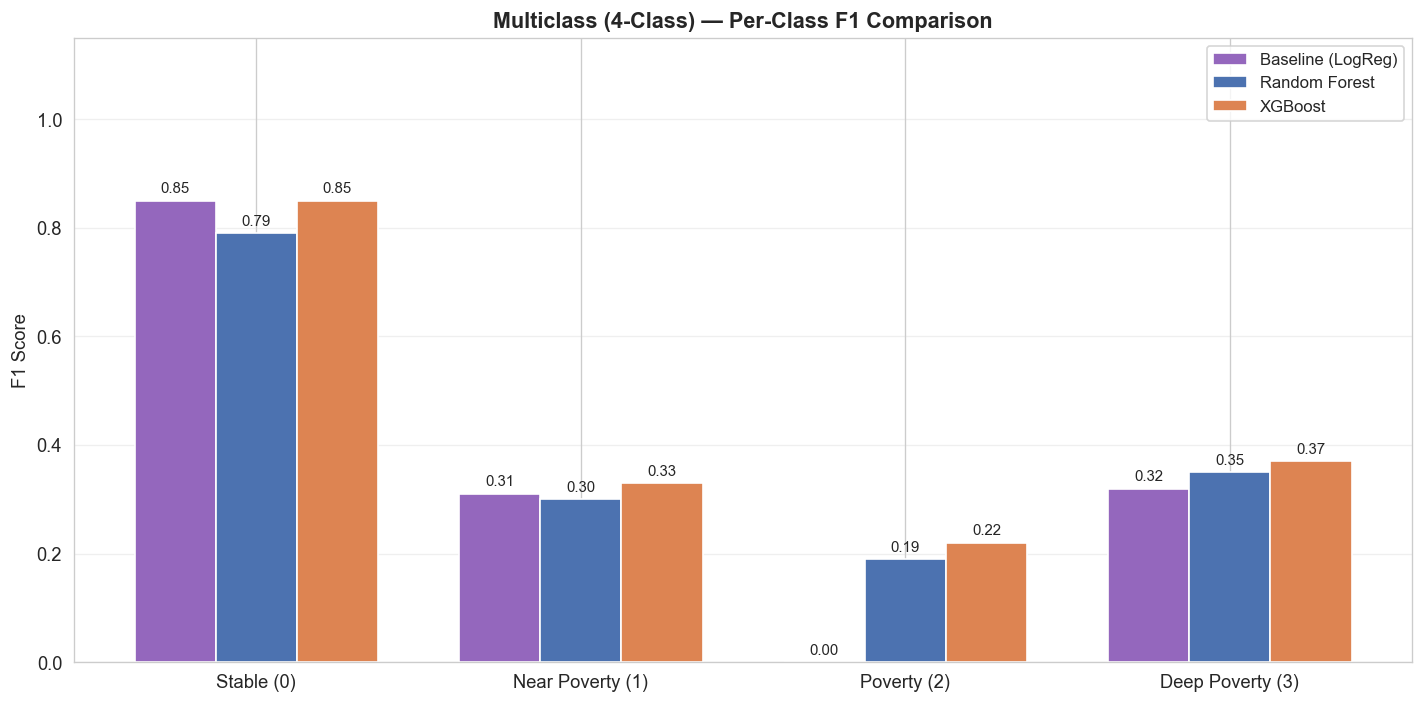

In [7]:
# ── Multiclass: Per-Class F1 Grouped Bar Chart ──
classes_4 = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']
models_multi = ['Baseline (LogReg)', 'Random Forest', 'XGBoost']

f1_baseline = [0.85, 0.31, 0.00, 0.32]
f1_rf       = [0.79, 0.30, 0.19, 0.35]
f1_xgb      = [0.85, 0.33, 0.22, 0.37]

x = np.arange(len(classes_4))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, f1_baseline, width, label='Baseline (LogReg)', color='#9467BD')
bars2 = ax.bar(x,         f1_rf,       width, label='Random Forest',     color='#4C72B0')
bars3 = ax.bar(x + width, f1_xgb,      width, label='XGBoost',           color='#DD8452')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes_4, fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.set_title('Multiclass (4-Class) — Per-Class F1 Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

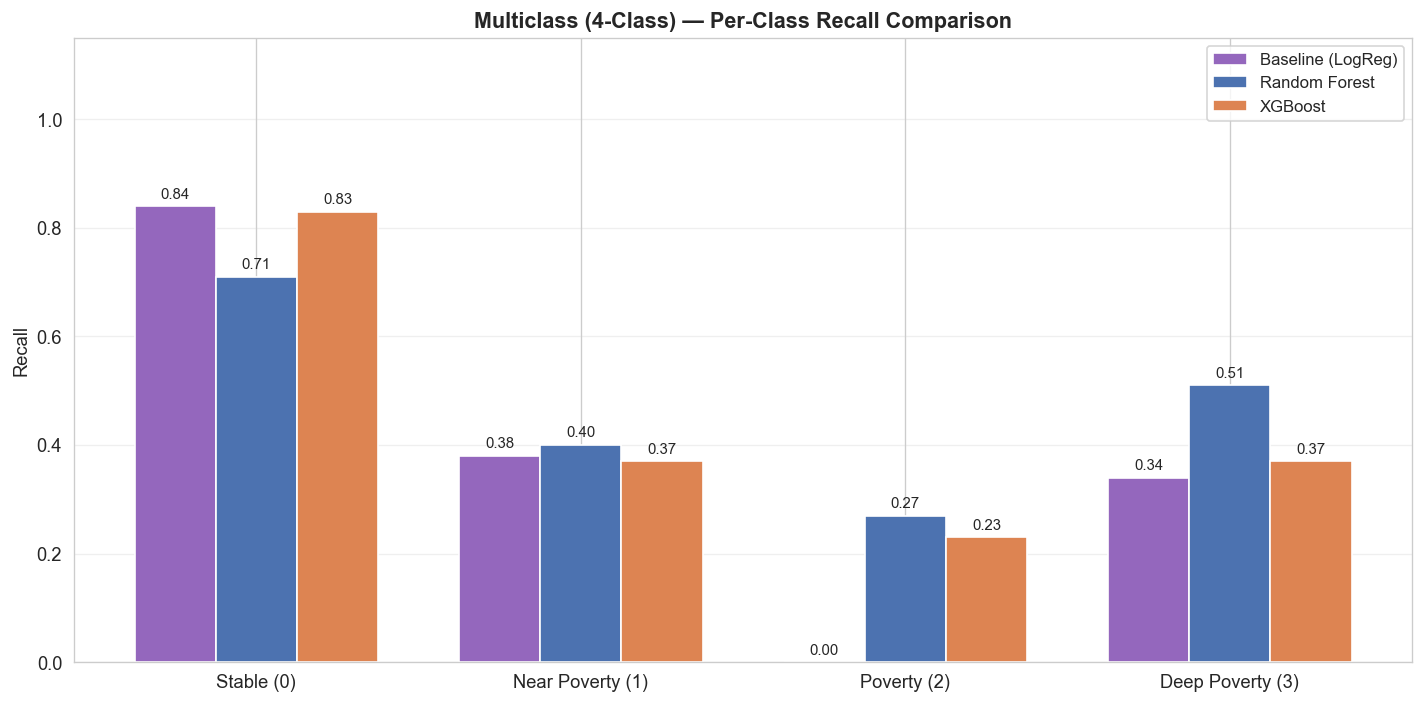

In [8]:
# ── Multiclass: Per-Class Recall Grouped Bar Chart ──
recall_baseline = [0.84, 0.38, 0.00, 0.34]
recall_rf       = [0.71, 0.40, 0.27, 0.51]
recall_xgb      = [0.83, 0.37, 0.23, 0.37]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, recall_baseline, width, label='Baseline (LogReg)', color='#9467BD')
bars2 = ax.bar(x,         recall_rf,       width, label='Random Forest',     color='#4C72B0')
bars3 = ax.bar(x + width, recall_xgb,      width, label='XGBoost',           color='#DD8452')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes_4, fontsize=11)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.15)
ax.set_title('Multiclass (4-Class) — Per-Class Recall Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Overall Model Scorecard

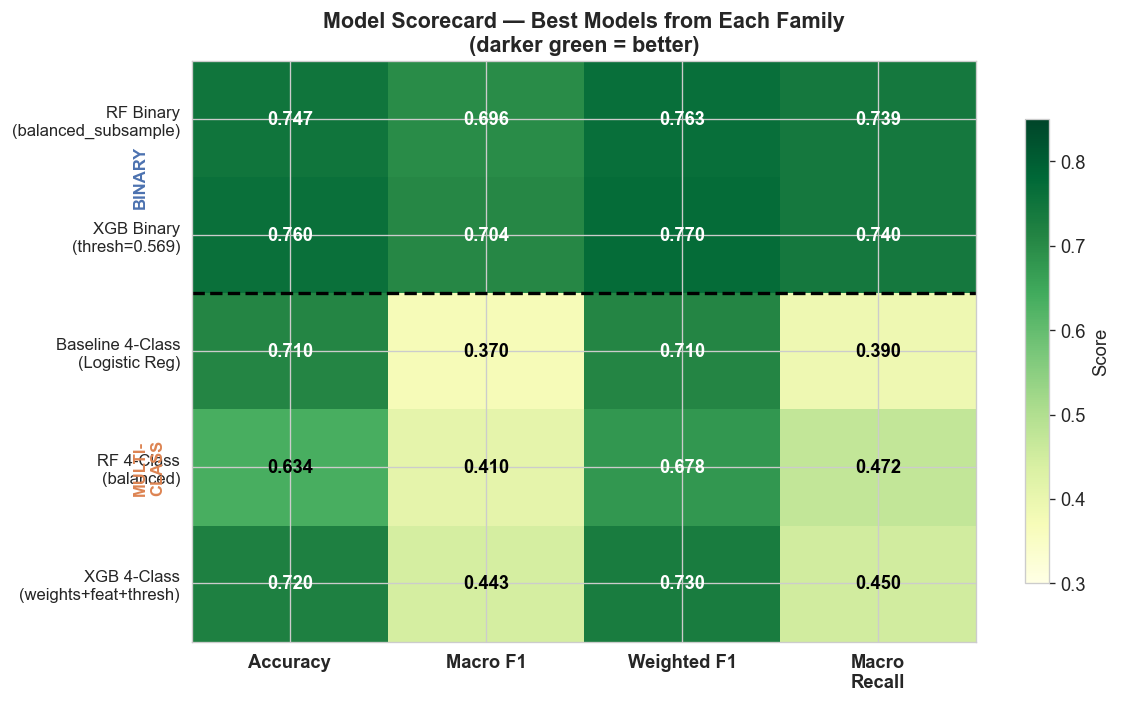

In [9]:
# ── Heatmap Scorecard: All Best Models × Key Metrics ──
scorecard_labels = [
    'RF Binary\n(balanced_subsample)',
    'XGB Binary\n(thresh=0.569)',
    'Baseline 4-Class\n(Logistic Reg)',
    'RF 4-Class\n(balanced)',
    'XGB 4-Class\n(weights+feat+thresh)',
]

metrics = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro\nRecall']

data = np.array([
    [0.7474, 0.6958, 0.7630, 0.7390],  # RF Binary
    [0.7598, 0.7044, 0.7700, 0.7400],  # XGB Binary
    [0.7100, 0.3700, 0.7100, 0.3900],  # Baseline 4-class
    [0.6341, 0.4100, 0.6779, 0.4725],  # RF 4-class
    [0.7200, 0.4431, 0.7300, 0.4500],  # XGB 4-class
])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(data, cmap='YlGn', aspect='auto', vmin=0.3, vmax=0.85)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(scorecard_labels)))
ax.set_yticklabels(scorecard_labels, fontsize=10)

# Annotate
for i in range(len(scorecard_labels)):
    for j in range(len(metrics)):
        val = data[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if val > 0.65 else 'black')

# Divider line between binary and multiclass
ax.axhline(1.5, color='black', linewidth=2, linestyle='--')
ax.text(-0.8, 0.5, 'BINARY', fontsize=10, fontweight='bold', va='center',
        rotation=90, color='#4C72B0')
ax.text(-0.8, 3.0, 'MULTI-\nCLASS', fontsize=10, fontweight='bold', va='center',
        rotation=90, color='#DD8452')

plt.colorbar(im, ax=ax, shrink=0.8, label='Score')
ax.set_title('Model Scorecard — Best Models from Each Family\n'
             '(darker green = better)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

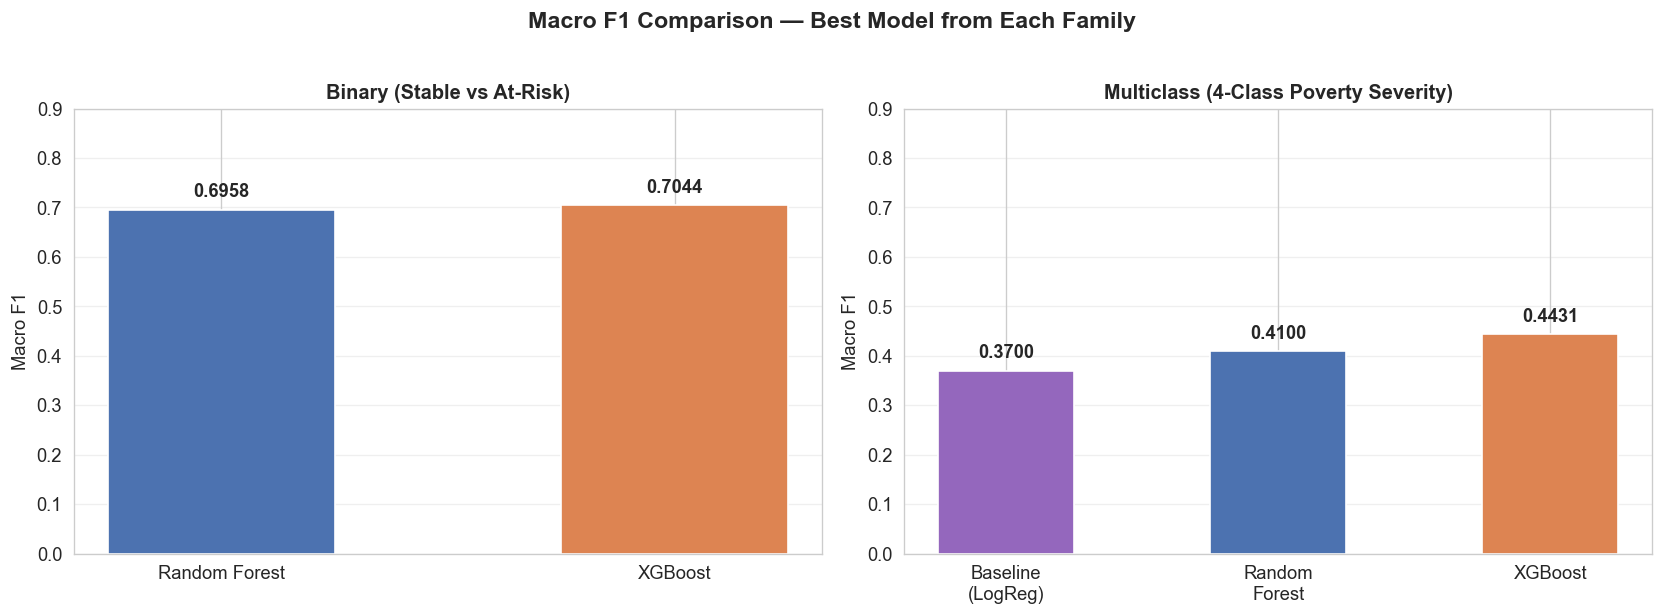

In [10]:
# ── Macro F1 Summary: Binary vs Multiclass ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
bin_models = ['Random Forest', 'XGBoost']
bin_f1     = [0.6958, 0.7044]
colors_bin = ['#4C72B0', '#DD8452']

bars = axes[0].bar(bin_models, bin_f1, color=colors_bin, width=0.5, edgecolor='white')
axes[0].bar_label(bars, fmt='%.4f', padding=5, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Macro F1')
axes[0].set_ylim(0, 0.9)
axes[0].set_title('Binary (Stable vs At-Risk)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Multiclass
multi_models_names = ['Baseline\n(LogReg)', 'Random\nForest', 'XGBoost']
multi_f1     = [0.37, 0.41, 0.4431]
colors_multi = ['#9467BD', '#4C72B0', '#DD8452']

bars = axes[1].bar(multi_models_names, multi_f1, color=colors_multi, width=0.5, edgecolor='white')
axes[1].bar_label(bars, fmt='%.4f', padding=5, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 0.9)
axes[1].set_title('Multiclass (4-Class Poverty Severity)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Macro F1 Comparison — Best Model from Each Family',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Normalized Confusion Matrices (Recall per Class)

Row-normalized confusion matrices show the **recall** (sensitivity) for each true class, making it easier to compare across models with different class distributions.

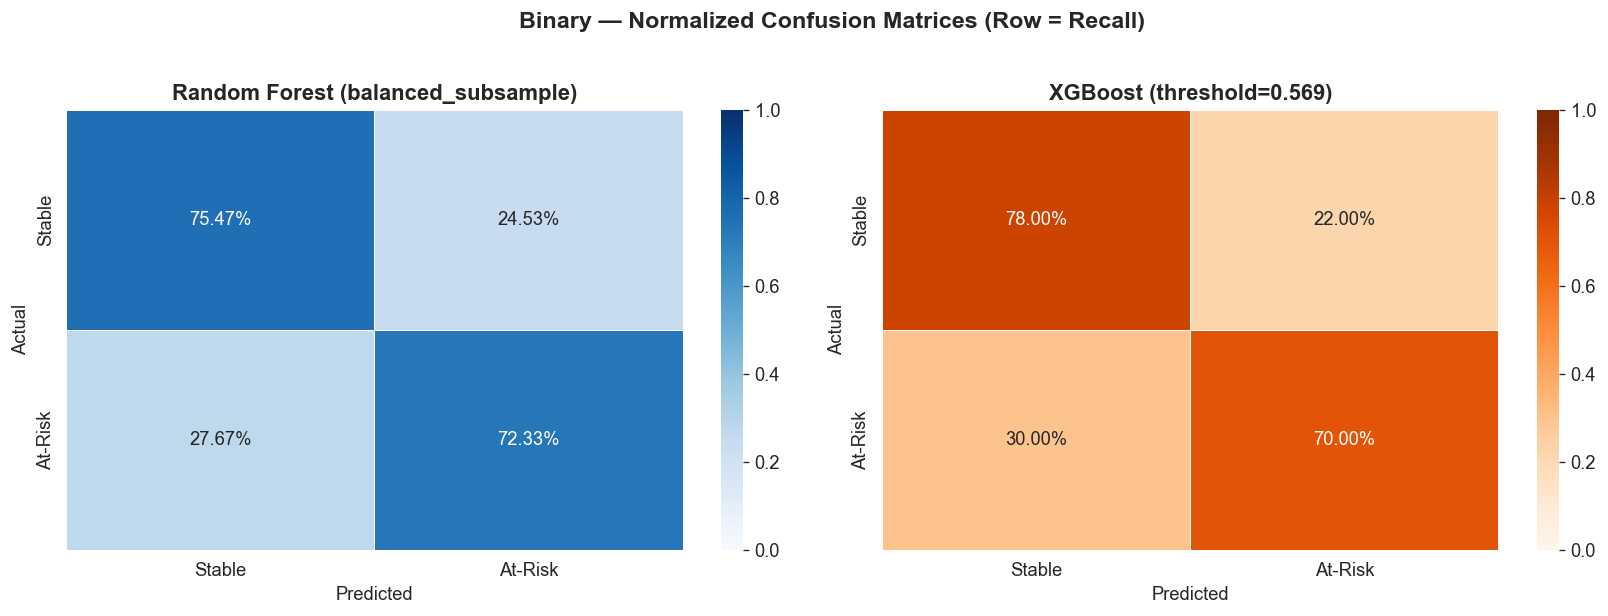

In [11]:
# ── Normalized Binary Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_bin, cm_xgb_bin],
    ['Random Forest (balanced_subsample)', 'XGBoost (threshold=0.569)'],
    ['Blues', 'Oranges']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap=cmap, ax=ax,
                xticklabels=binary_labels, yticklabels=binary_labels,
                vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Binary — Normalized Confusion Matrices (Row = Recall)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

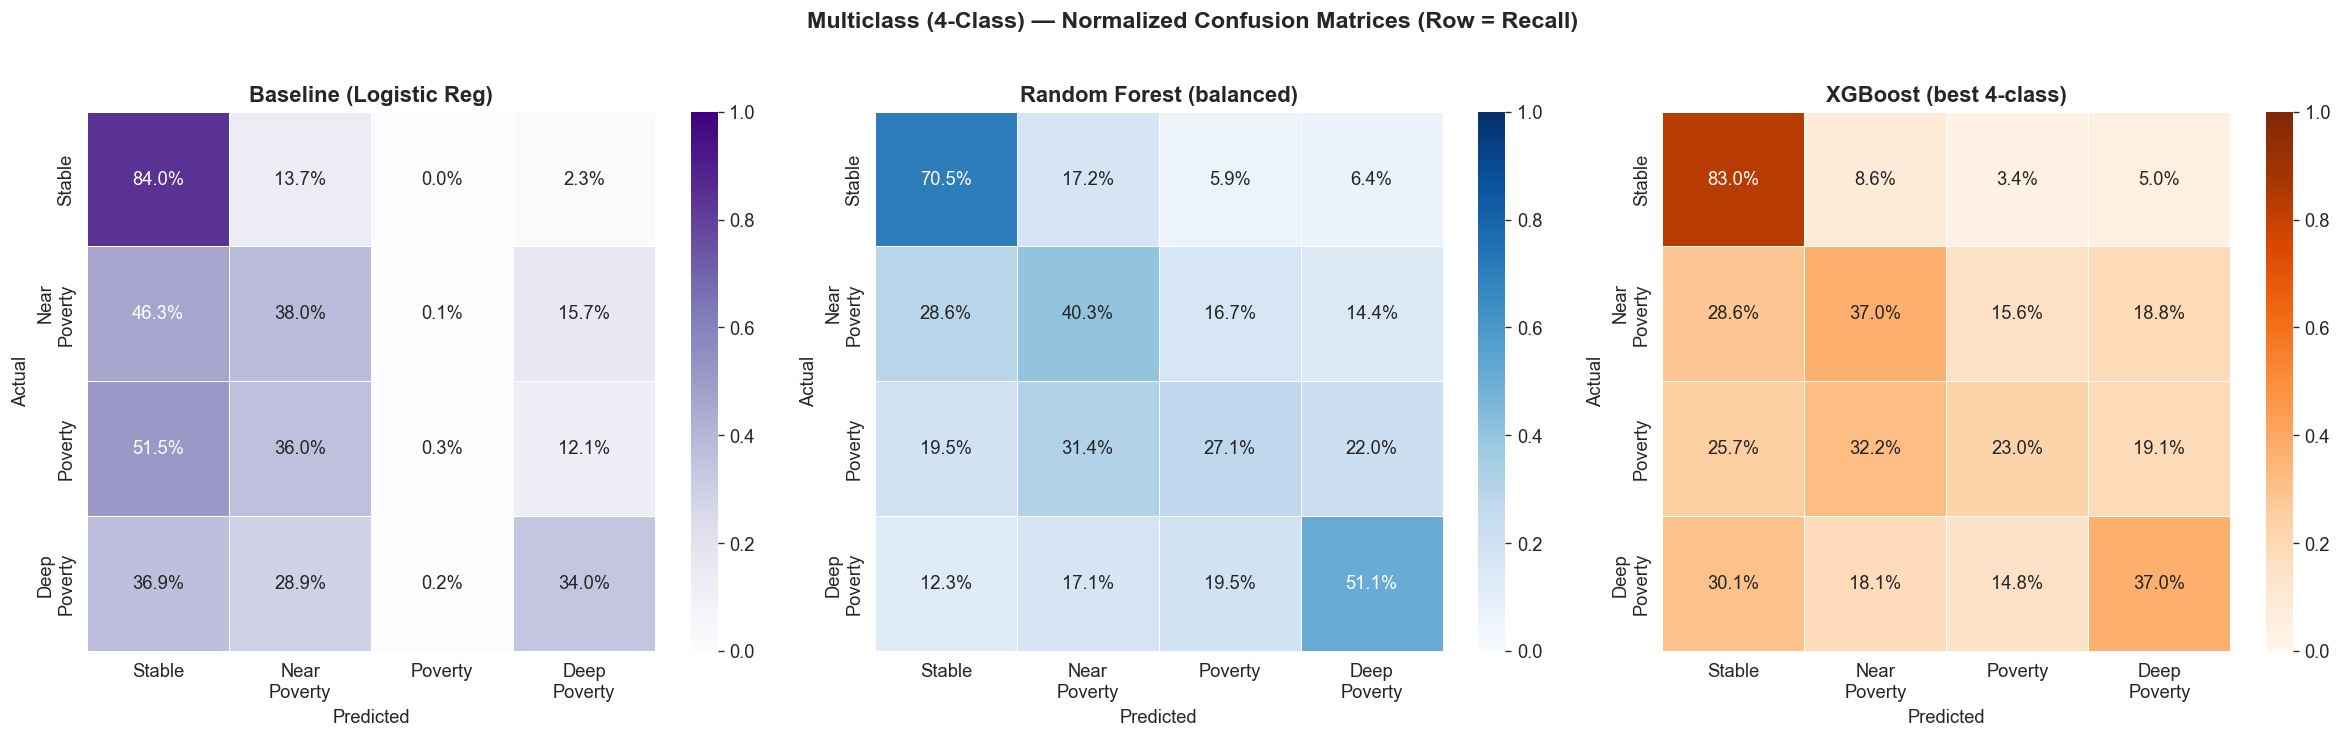

In [12]:
# ── Normalized Multiclass Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_base, cm_rf_multi, cm_xgb_multi],
    ['Baseline (Logistic Reg)', 'Random Forest (balanced)', 'XGBoost (best 4-class)'],
    ['Purples', 'Blues', 'Oranges']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=cmap, ax=ax,
                xticklabels=multi_labels, yticklabels=multi_labels,
                vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Multiclass (4-Class) — Normalized Confusion Matrices (Row = Recall)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Key Takeaways

In [13]:
print('''
==============================================================================
KEY TAKEAWAYS
==============================================================================

BINARY CLASSIFICATION (Stable vs At-Risk)
──────────────────────────────────────────
  Best Model: XGBoost with optimized threshold (0.569)
    - Macro F1:     0.7044
    - Accuracy:     0.76
    - At-Risk F1:   0.58  |  At-Risk Recall: 0.70

  Runner-Up: Random Forest (balanced_subsample)
    - Macro F1:     0.6958
    - Accuracy:     0.75
    - At-Risk F1:   0.57  |  At-Risk Recall: 0.72

  Note: RF has slightly higher at-risk recall (0.72 vs 0.70),
        but XGBoost wins on overall F1 and accuracy.

MULTICLASS (4-Class Poverty Severity)
──────────────────────────────────────────
  Best Model: XGBoost (sample weights + engineered features + thresholds)
    - Macro F1:     0.4431
    - Accuracy:     0.72
    - Improved on ALL minority classes vs baseline

  Runner-Up: Random Forest (balanced)
    - Macro F1:     0.4100
    - Best Deep Poverty recall (0.51) of all models

  Baseline: Logistic Regression
    - Macro F1:     0.37
    - CRITICAL: Poverty class (2) F1 = 0.00 (completely missed)
    - Highest Stable recall (0.84) but at cost of minority classes

COMMON CHALLENGE
──────────────────────────────────────────
  - Near Poverty (1) and Poverty (2) remain the hardest classes
  - All models struggle to distinguish adjacent poverty levels
  - Binary framing (Stable vs At-Risk) is far more reliable
    than fine-grained 4-class severity prediction
  - XGBoost consistently achieves the best Macro F1 for both tasks

==============================================================================
''')


KEY TAKEAWAYS

BINARY CLASSIFICATION (Stable vs At-Risk)
──────────────────────────────────────────
  Best Model: XGBoost with optimized threshold (0.569)
    - Macro F1:     0.7044
    - Accuracy:     0.76
    - At-Risk F1:   0.58  |  At-Risk Recall: 0.70

  Runner-Up: Random Forest (balanced_subsample)
    - Macro F1:     0.6958
    - Accuracy:     0.75
    - At-Risk F1:   0.57  |  At-Risk Recall: 0.72

  Note: RF has slightly higher at-risk recall (0.72 vs 0.70),
        but XGBoost wins on overall F1 and accuracy.

MULTICLASS (4-Class Poverty Severity)
──────────────────────────────────────────
  Best Model: XGBoost (sample weights + engineered features + thresholds)
    - Macro F1:     0.4431
    - Accuracy:     0.72
    - Improved on ALL minority classes vs baseline

  Runner-Up: Random Forest (balanced)
    - Macro F1:     0.4100
    - Best Deep Poverty recall (0.51) of all models

  Baseline: Logistic Regression
    - Macro F1:     0.37
    - CRITICAL: Poverty class (2) F1 = 0